In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
red_wine_df = pd.read_csv("data/winequality-red.csv", sep=";")
white_wine_df = pd.read_csv("data/winequality-white.csv", sep=";")

In [61]:
red_wine_df["Is Red Wine"] = 1
white_wine_df["Is Red Wine"] = 0

In [62]:
wine_df = pd.concat([red_wine_df, white_wine_df], join="inner")

In [63]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Is Red Wine
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

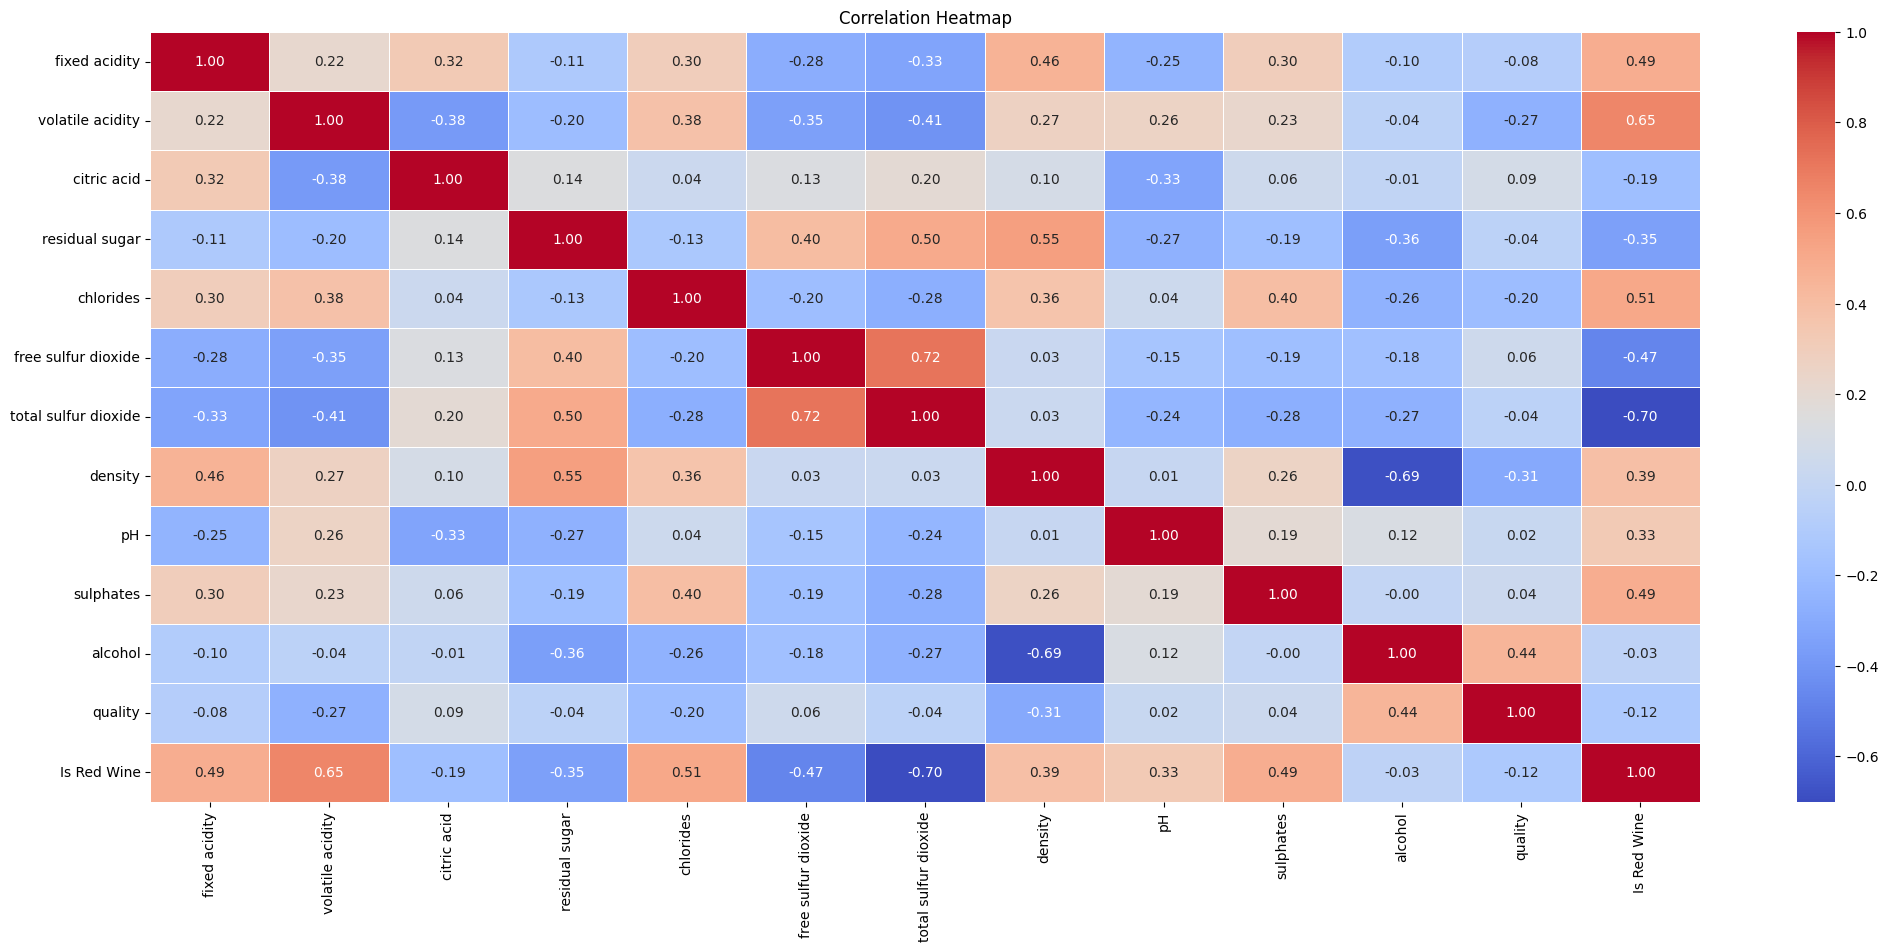

In [68]:
correlation_matrix = wine_df.corr()
plt.figure(figsize=(25,10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidth=0.5)
plt.title("Correlation Heatmap")


We can see a strong correlation between sulphates/sulfur dioxide, and acidity and Is Red Wine which should make classification easy.

In [123]:
def absolute_max_scale(series):
    return series / series.abs().max()

normalized_wine_df = wine_df.copy()

for column in normalized_wine_df.columns:
    normalized_wine_df[column] = absolute_max_scale(normalized_wine_df[column])


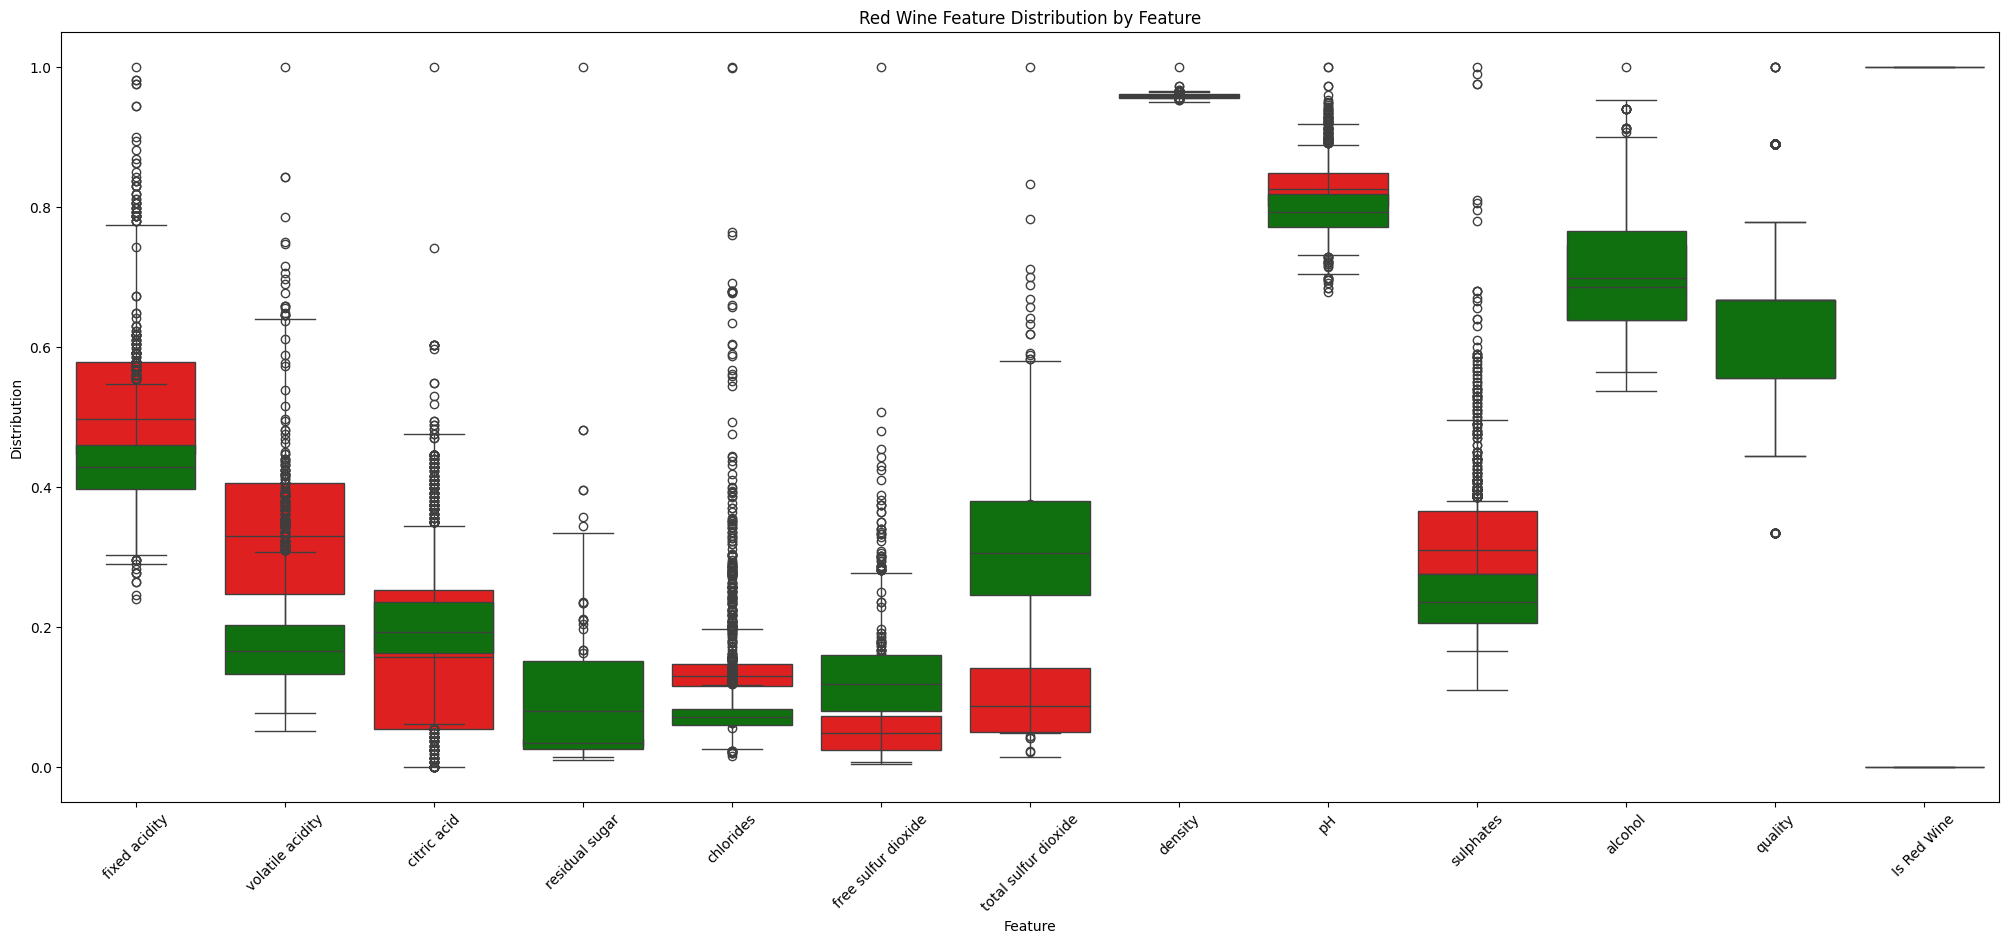

In [124]:
labels = list(normalized_wine_df.columns)

plt.figure(figsize=(25,10))
sns.boxplot(normalized_wine_df[normalized_wine_df["Is Red Wine"] == 1], color="red")
sns.boxplot(normalized_wine_df[normalized_wine_df["Is Red Wine"] == 0], color="green")
plt.xticks(np.arange(len(labels)), labels,rotation=45)
plt.title("Red Wine Feature Distribution by Feature")
plt.xlabel("Feature")
plt.ylabel("Distribution")
plt.show()

To confirm the correlation matrix, there are several features that provide a decent amount of separation between red and white wine, such as sulphates, total sulfur dioxide, free sulfur dioxides, chlorides, and volatile acidity. Other features don't provide a lot of separation between the two groups, such as fixed acidity (this provides some separation between the two types but it may not be enough for an algorithm) and quality. 

I normalized the data so that everything could be graphed on the same axes by dividing everything by the absolute of the max value of each column. 